# Procesamiento Digital de Imágenes
## Guía de Trabajos Prácticos 3 — Filtrado en el dominio espacial
**FICH, UNL — Ingeniería Informática**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import output
output.enable_custom_widget_manager()

import os

ruta = '/content/drive/MyDrive/Practica PDI - Santiago Bargas/Practica 3'
os.chdir(ruta)

print("Archivos en la carpeta:")
for f in os.listdir(ruta):
    print(f" ·", f)

## Ejercicio 1: Filtros pasa-bajos

✅ Procesando: Deforestacion.png


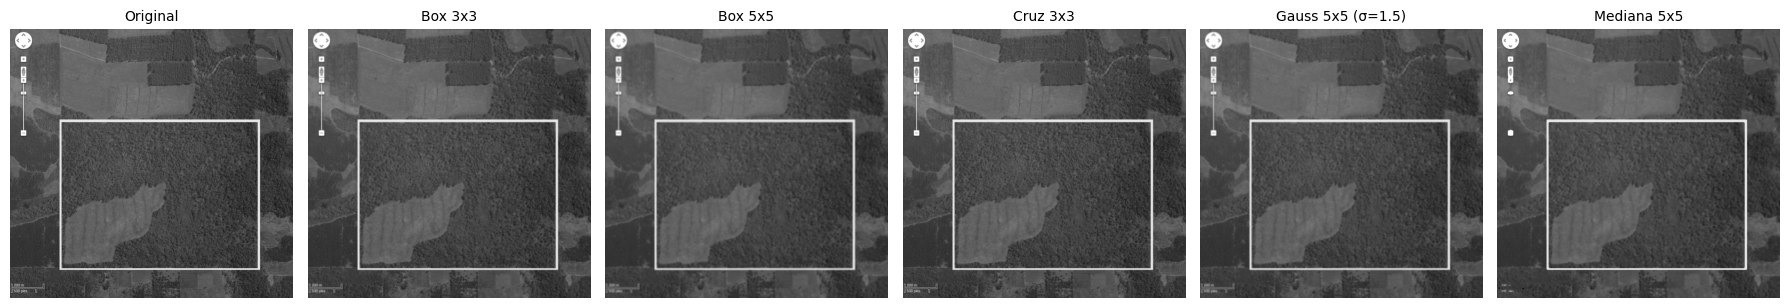

✅ Procesando: chairs.jpg


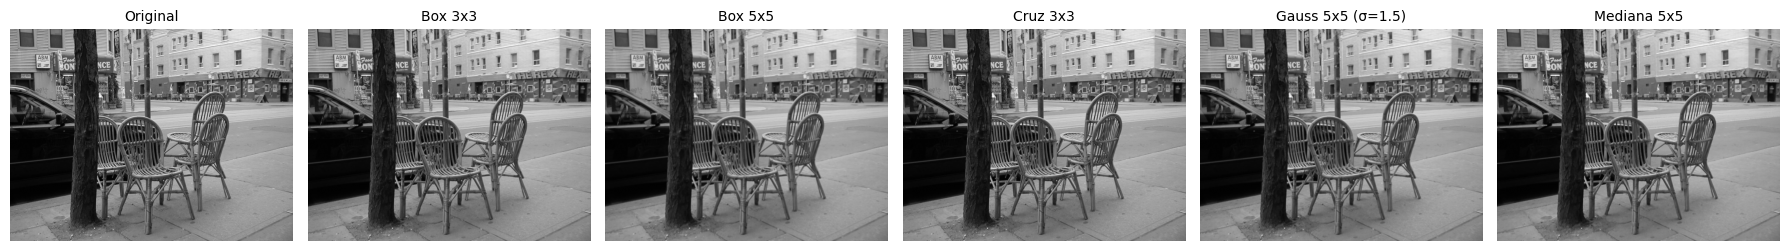

✅ Procesando: hubble.tif (objetos grandes)


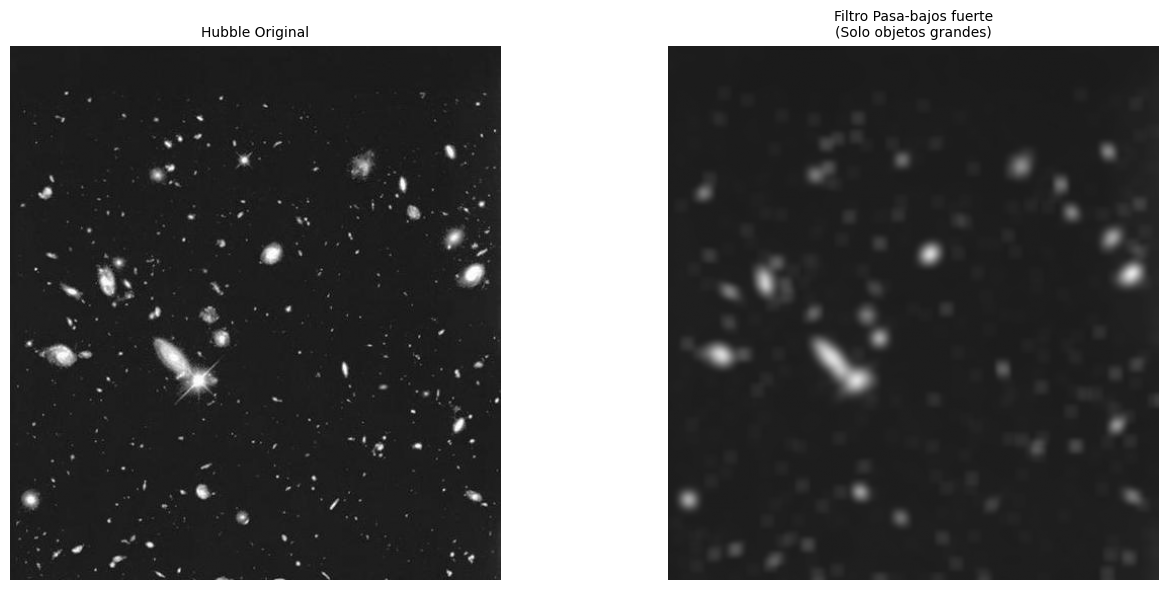

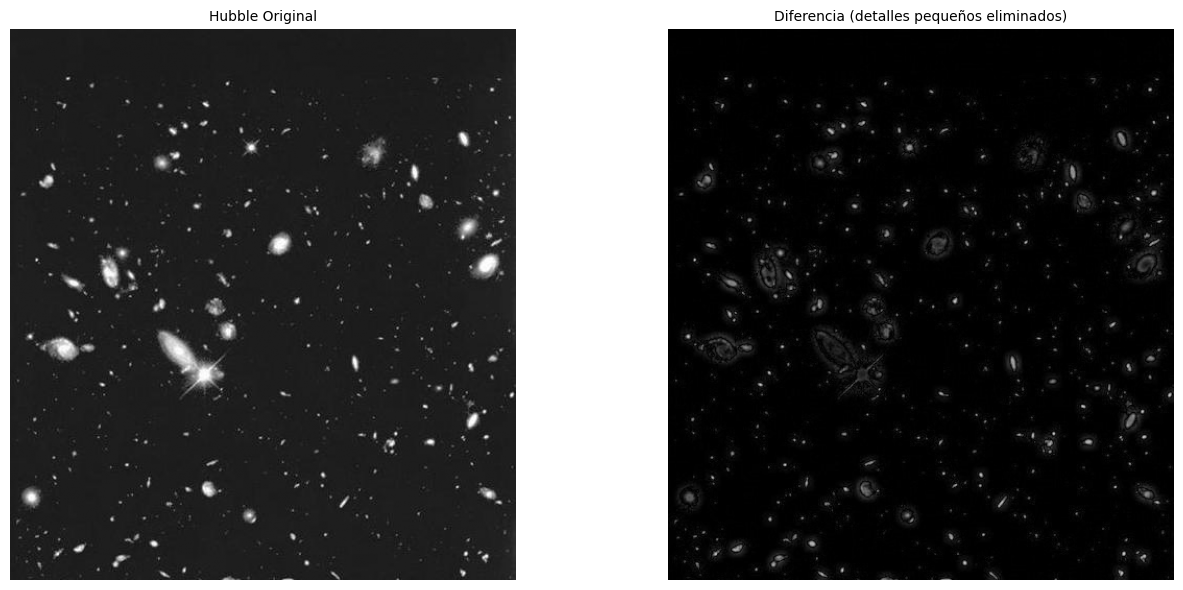

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mostrar_comparacion(titulos, imagenes, figsize=(18, 4)):
    n = len(imagenes)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        cmap = 'gray' if len(imagenes[i].shape) == 2 else None
        plt.imshow(imagenes[i], cmap=cmap, vmin=0, vmax=255)
        plt.title(titulos[i], fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Lista de archivos a procesar
nombres_archivos = ['Deforestacion.png', 'chairs.jpg']

# Definimos los kernels  
kernels = {
    "Box 3x3": np.ones((3, 3), np.float32) / 9,
    "Box 5x5": np.ones((5, 5), np.float32) / 25,
    "Cruz 3x3": np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]], dtype=np.float32) / 5
}

for nombre in nombres_archivos:
    img = cv2.imread(nombre, cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    
    print(f"✅ Procesando: {nombre}")
    
    # --- 1.1 y 1.2: Filtros Lineales (Box y Gaussiano) ---
    res = [img]; tit = ["Original"]
    for k_nombre, kernel in kernels.items():
        res.append(cv2.filter2D(img, -1, kernel))
        tit.append(k_nombre)
    
    res.append(cv2.GaussianBlur(img, (5, 5), 1.5))
    tit.append("Gauss 5x5 (σ=1.5)")
    
    # --- 1.3: Filtro de Mediana (No lineal) ---
    res.append(cv2.medianBlur(img, 5))
    tit.append("Mediana 5x5")
    
    mostrar_comparacion(tit, res)

# --- 1.4: Localización de objetos grandes (Hubble) ---
hubble = cv2.imread('hubble.tif', cv2.IMREAD_GRAYSCALE)

if hubble is not None:
    print("✅ Procesando: hubble.tif (objetos grandes)")
    # Filtro pasa-bajos fuerte para eliminar estrellas pequeñas y dejar solo galaxias grandes
    hubble_grande = cv2.GaussianBlur(hubble, (15, 15), sigmaX=6)

    mostrar_comparacion(
        ["Hubble Original", "Filtro Pasa-bajos fuerte\n(Solo objetos grandes)"],
        [hubble, hubble_grande],
        figsize=(14, 6)
    )
    
    # Opcional: Mostrar la diferencia (detalles eliminados)
    diferencia = cv2.absdiff(hubble, hubble_grande)
    mostrar_comparacion(
        ["Hubble Original", "Diferencia (detalles pequeños eliminados)"],
        [hubble, diferencia],
        figsize=(14, 6)
    )
else:
    print("⚠️ No se encontró el archivo 'hubble.tif'")

Comparación Lineal vs. No Lineal: Filtro de Mediana es mucho mejor preservando los bordes de los objetos que el filtro de caja o Gaussiano. Esto ocurre porque la mediana no calcula un promedio aritmético, sino que elige el valor central, eliminando el ruido "sal y pimienta" sin difuminar tanto las estructuras reales.

Localización de objetos: Al usar un filtro de caja de tamaño grande, estamos aplicando un filtro pasa-bajos muy severo. Esto actúa como una máscara que ignora las variaciones de alta frecuencia (puntos pequeños/estrellas) y deja pasar solo las de baja frecuencia (manchas grandes/galaxias), permitiendo aislarlas visualmente.

## Ejercicio 2: Filtros pasa-altas

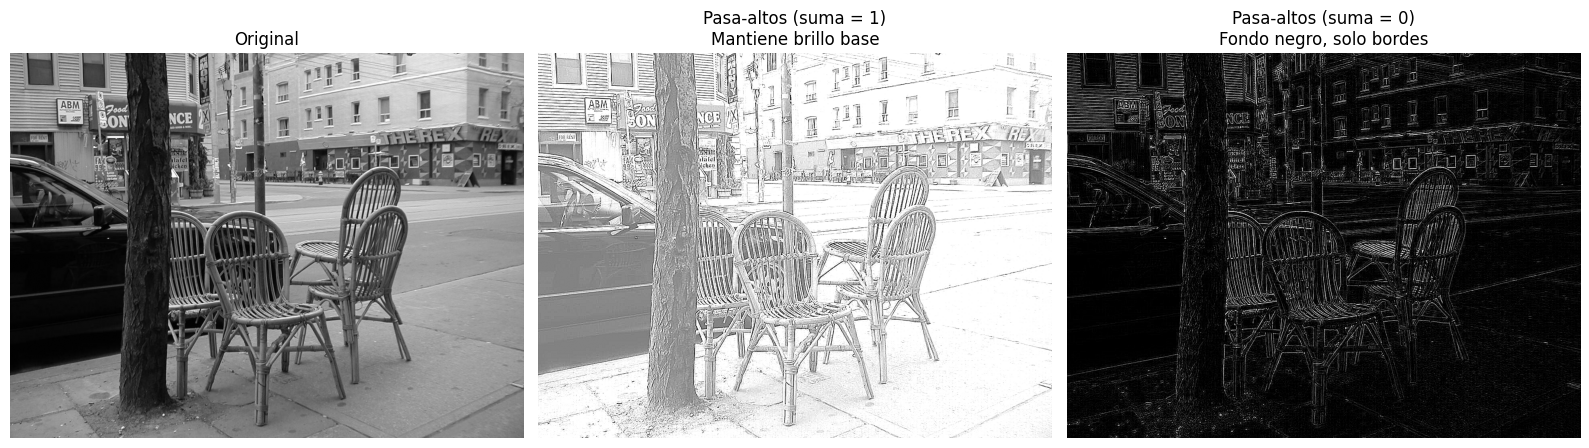

In [13]:
img = cv2.imread('chairs.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error cargando chairs.jpg")
else:
    f = img.astype(np.float32)

    # -------------------------------------------------
    # 2.1 Máscara pasa-altos con suma de coeficientes = 1
    # -------------------------------------------------
    kernel_suma1 = np.array([[-1, -1, -1],
                             [-1,  9, -1],
                             [-1, -1, -1]], dtype=np.float32)

    # -------------------------------------------------
    # 2.2 Máscara pasa-altos con suma de coeficientes = 0
    # -------------------------------------------------
    kernel_suma0 = np.array([[-1, -1, -1],
                             [-1,  8, -1],
                             [-1, -1, -1]], dtype=np.float32)

    # Aplicamos los filtros
    pasa_alto_suma1 = cv2.filter2D(f, -1, kernel_suma1)
    pasa_alto_suma0 = cv2.filter2D(f, -1, kernel_suma0)

    # Visualización
    fig, axs = plt.subplots(1, 3, figsize=(16, 6))

    axs[0].imshow(img, cmap='gray')
    axs[0].set_title('Original')
    axs[0].axis('off')

    axs[1].imshow(np.clip(pasa_alto_suma1 + 128, 0, 255).astype(np.uint8), cmap='gray')
    axs[1].set_title('Pasa-altos (suma = 1)\nMantiene brillo base')
    axs[1].axis('off')

    axs[2].imshow(np.clip(pasa_alto_suma0, 0, 255).astype(np.uint8), cmap='gray')
    axs[2].set_title('Pasa-altos (suma = 0)\nFondo negro, solo bordes')
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()


## Ejercicio 3: Filtros de acentuado

--- EJERCICIO 3: Filtros de Acentuado ---


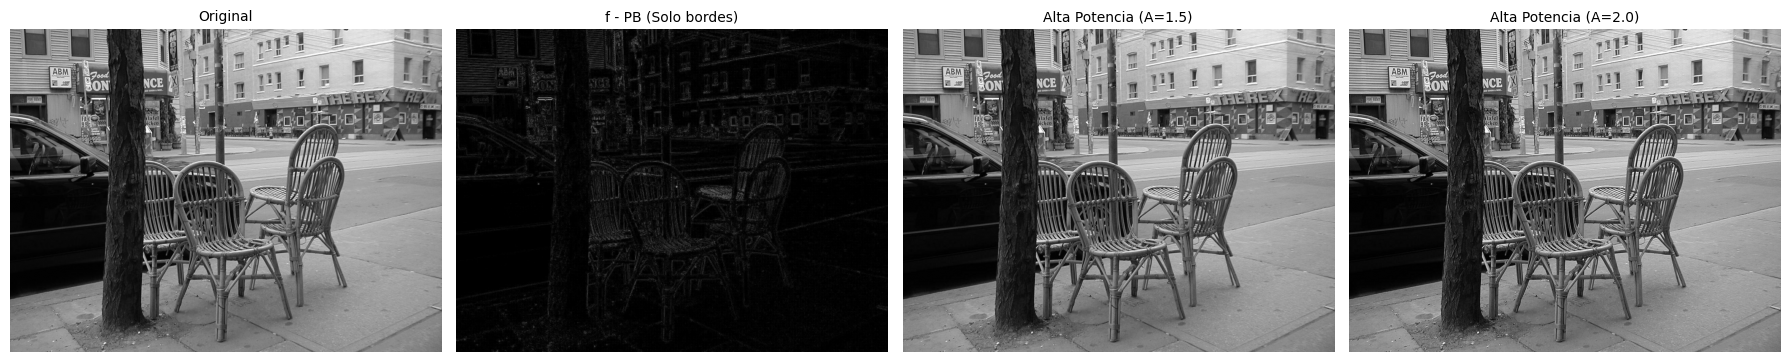

--- Método de Una Pasada (Kernel Combinado para A=2.0) ---


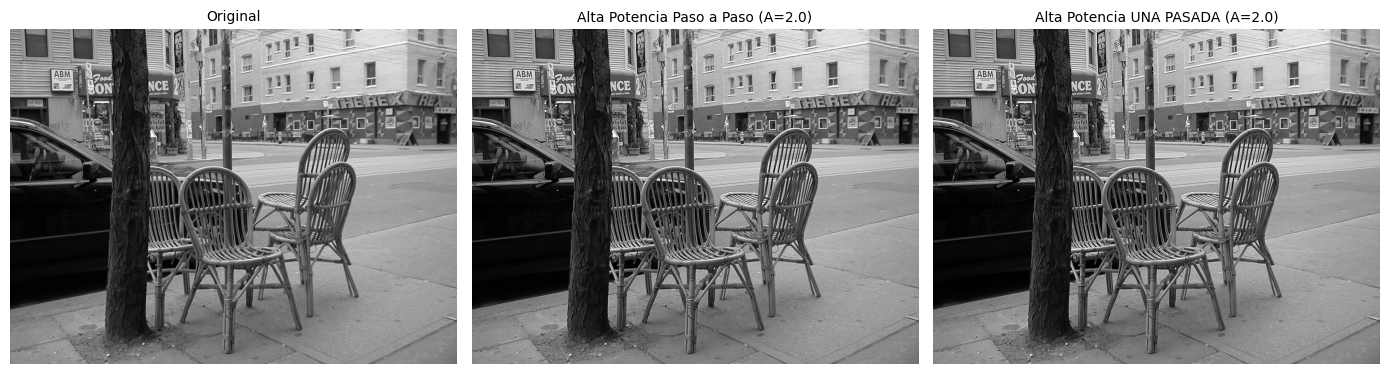

In [22]:
img = cv2.imread('chairs.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error")
else:
    print("--- EJERCICIO 3: Filtros de Acentuado ---")

    # 1. CONVERSIÓN A FLOAT PARA NO PERDER DATOS
    f = img.astype(np.float32)

    #Creamos el pasa bajos
    pb=cv2.blur(f,(3,3))

    # ---------------------------------------------------------
    # PUNTO 3.1: Máscara Difusa Básica (A = 1) -> g = f - PB
    # ---------------------------------------------------------
    # Esto aísla los bordes. Le sumamos 128 visualmente para que el fondo 
    # quede gris y los bordes se vean claros/oscuros.
    mascara_bordes = cv2.absdiff(f, pb)

    img_bordes = cv2.normalize(
        mascara_bordes,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    # ---------------------------------------------------------
    # PUNTO 3.2: Alta Potencia (A > 1) -> g = A*f - PB
    # ---------------------------------------------------------
    A1 = 1.1 
    g_A1 = f + (A1 - 1) * (f - pb) # (f - pb) es el filtro pasa-altos

    A2 = 2.0
    g_A2 = f + (A2 - 1) * (f - pb)

    # Recortamos y convertimos (esto evita que se vea oscura)
    img_g_A1 = np.clip(g_A1, 0, 255).astype(np.uint8)
    img_g_A2 = np.clip(g_A2, 0, 255).astype(np.uint8)

    mostrar_comparacion(
        ["Original", "f - PB (Solo bordes)", "Alta Potencia (A=1.5)", "Alta Potencia (A=2.0)"],
        [img, img_bordes, img_g_A1, img_g_A2]
    )

    # ---------------------------------------------------------
    # MÉTODO ALTERNATIVO: CÁLCULO EN UNA PASADA
    # ---------------------------------------------------------
    print("--- Método de Una Pasada (Kernel Combinado para A=2.0) ---")
    
    A_una_pasada = 2.0
    
    # 1. Matriz Identidad
    identidad = np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]], dtype=np.float32)
                          
    # 2. Matriz del Box Filter (1/9)
    box_filter = np.ones((3, 3), dtype=np.float32) / 9.0
    
    # 3. Kernel final combinado matemáticamente
    kernel_una_pasada = (A_una_pasada * identidad) - box_filter
    
    # Aplicamos directo a la original con cv2.filter2D
    g_una_pasada_raw = cv2.filter2D(f, -1, kernel_una_pasada)
    img_una_pasada = np.clip(g_una_pasada_raw, 0, 255).astype(np.uint8)

    mostrar_comparacion(
        ["Original", "Alta Potencia Paso a Paso (A=2.0)", "Alta Potencia UNA PASADA (A=2.0)"],
        [img, img_g_A2, img_una_pasada],
        figsize=(14, 5)
    )



## Ejercicio 4: Trabajos de aplicacion

--- PUNTO 4.1: Pipeline de Realce de Esqueleto ---


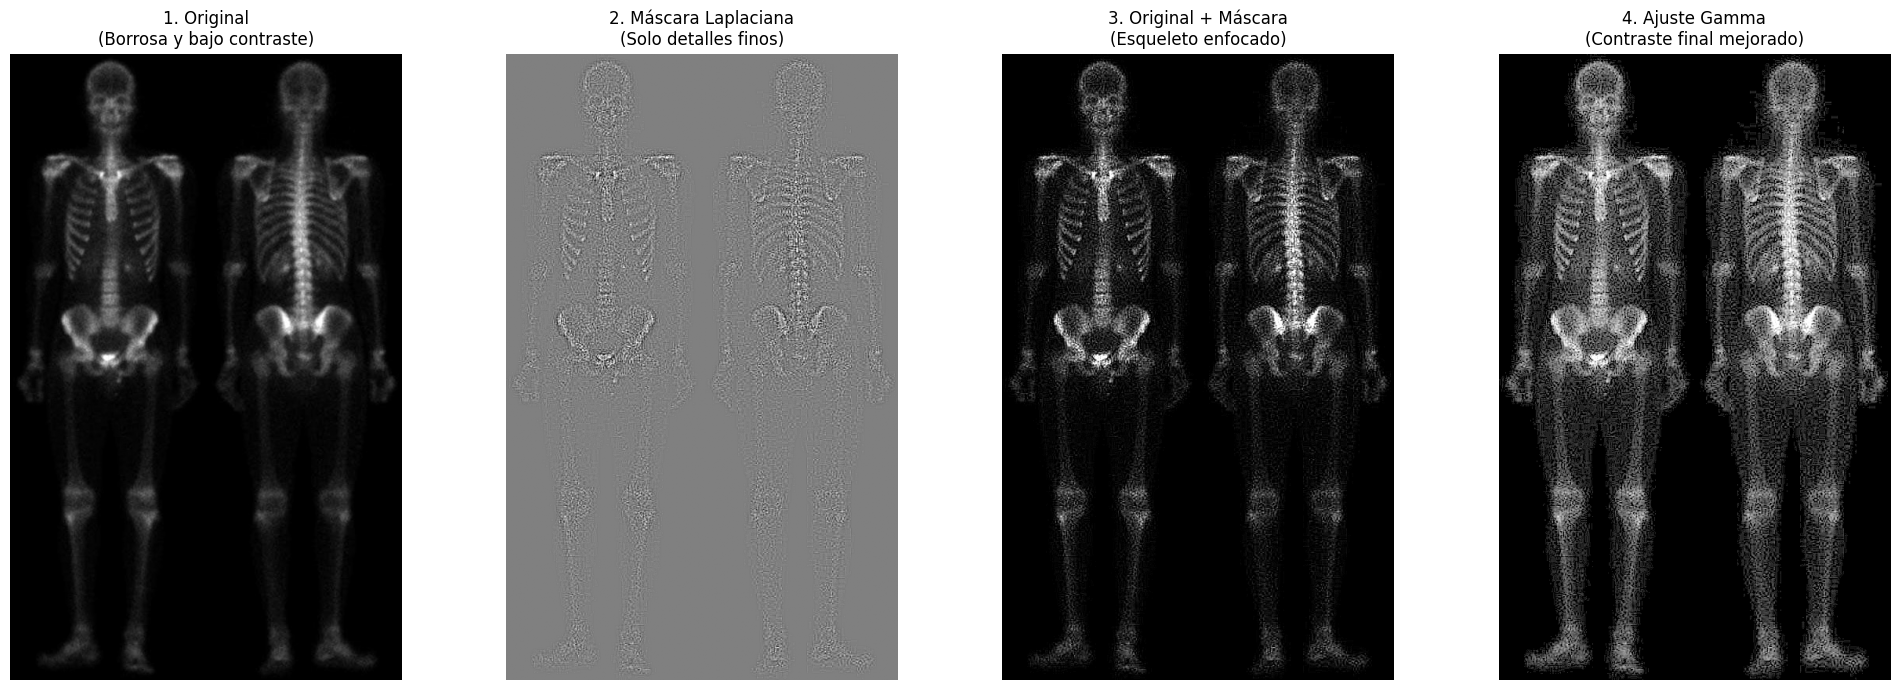

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargamos la imagen
img = cv2.imread('esqueleto.tif', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("❌ Error: No se encuentra 'esqueleto.tif'.")
else:
    print("--- PUNTO 4.1: Pipeline de Realce de Esqueleto ---")
    
    # 1. Pasamos a float32 para poder tener valores negativos al restar y sumar
    f = img.astype(np.float32)
    
    # 2. LAPLACIANO (Extracción de bordes)
    # Usamos un filtro agresivo que incluya las diagonales para captar todos los detalles de los huesos
    kernel_laplace = np.array([[-1, -1, -1],
                               [-1,  8, -1],
                               [-1, -1, -1]], dtype=np.float32)
    
    bordes = cv2.filter2D(f, -1, kernel_laplace)
    
    # 3. SHARPENING (Enfoque sumando bordes a la original)
    esq_enfocado = f + bordes
    
    # 4. TRANSFORMACIÓN GAMMA (Mejora de contraste)
    # Como la imagen enfocada sigue siendo un poco oscura, le aplicamos un gamma < 1 
    # para expandir los grises claros y que el esqueleto "brille" más.
    gamma = 0.5
    esq_final = np.power(np.clip(esq_enfocado, 0, 255) / 255.0, gamma) * 255.0
    
    # --- Preparamos todo para graficar (recortando a 0-255 y pasando a uint8) ---
    esq_final = np.clip(esq_final, 0, 255).astype(np.uint8)
    esq_enfocado_vis = np.clip(esq_enfocado, 0, 255).astype(np.uint8)
    
    # A los bordes les sumamos 128 solo para que el fondo se vea gris y los detalles resalten
    bordes_visibles = np.clip(bordes + 128, 0, 255).astype(np.uint8)

    # --- Graficamos el paso a paso ---
    plt.figure(figsize=(20, 7))
    
    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title('1. Original\n(Borrosa y bajo contraste)')
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(bordes_visibles, cmap='gray', vmin=0, vmax=255)
    plt.title('2. Máscara Laplaciana\n(Solo detalles finos)')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.imshow(esq_enfocado_vis, cmap='gray', vmin=0, vmax=255)
    plt.title('3. Original + Máscara\n(Esqueleto enfocado)')
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.imshow(esq_final, cmap='gray', vmin=0, vmax=255)
    plt.title('4. Ajuste Gamma\n(Contraste final mejorado)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

--- PUNTO 4.2: Comparación Bilateral vs Gaussiano ---

Procesando: lapices02.jpg


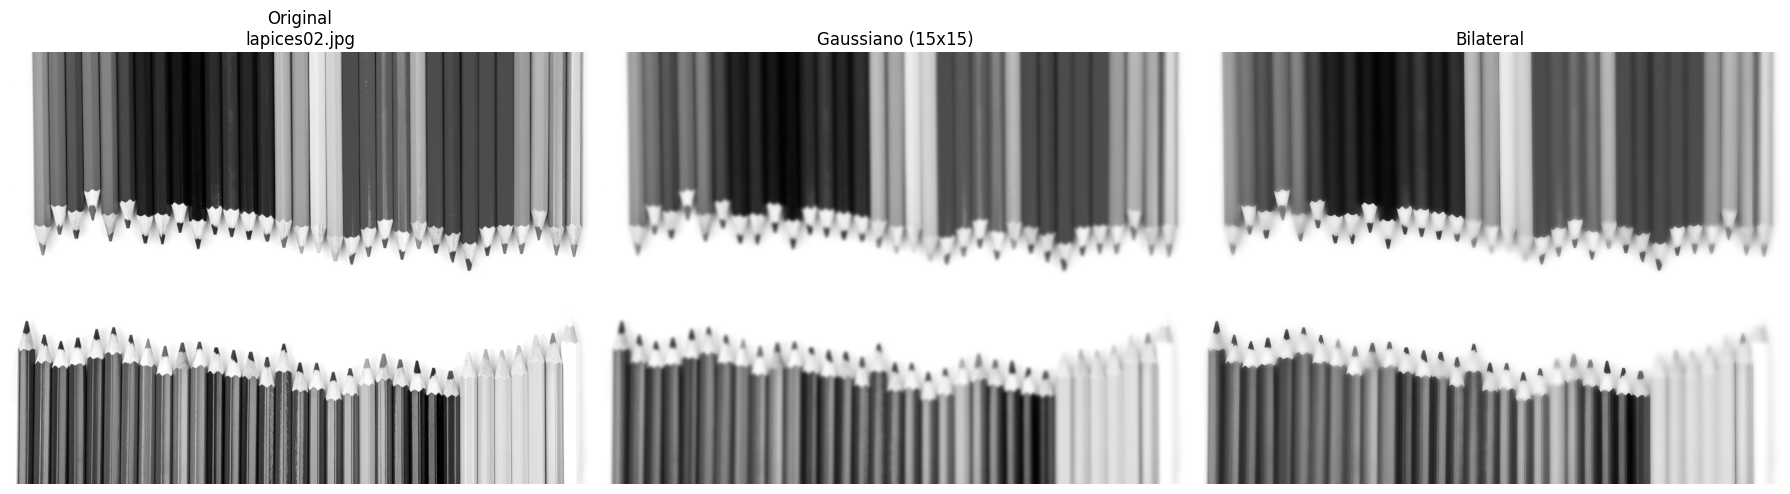

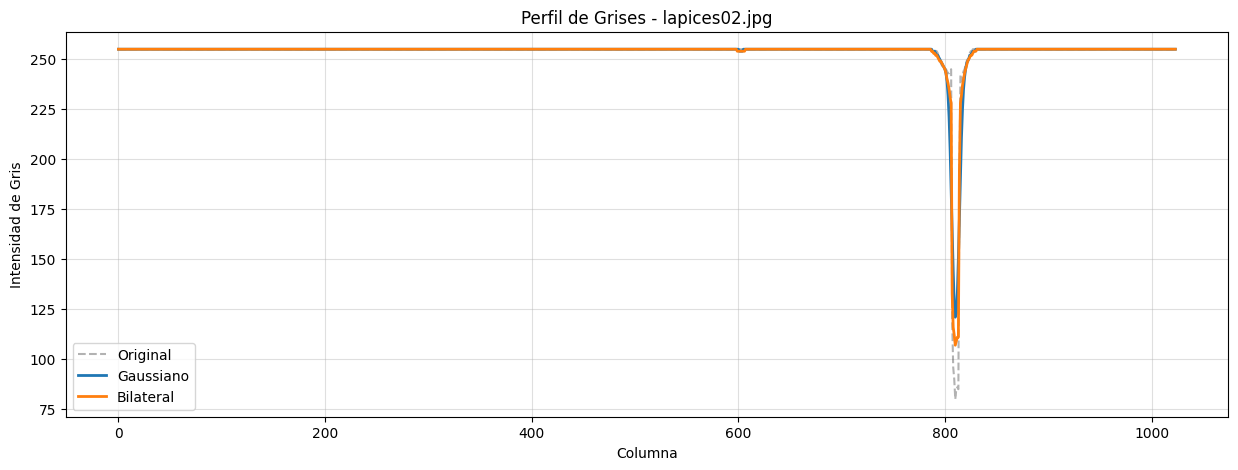


Procesando: mariposa02.png


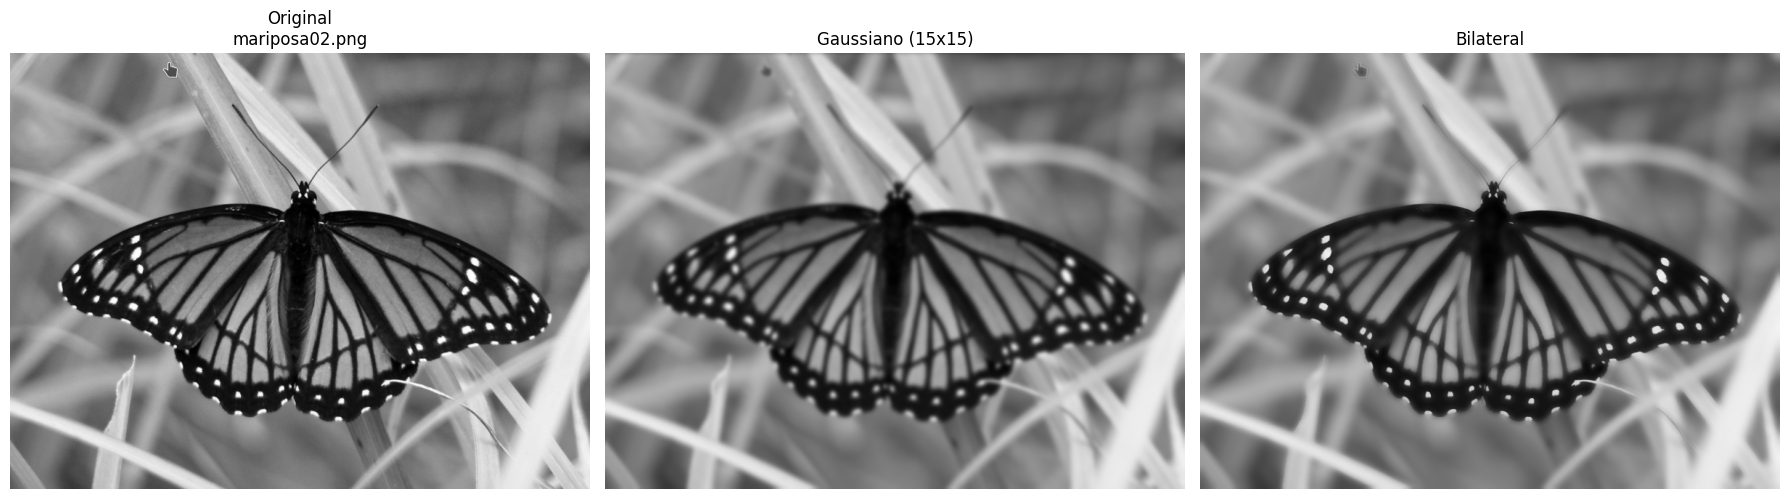

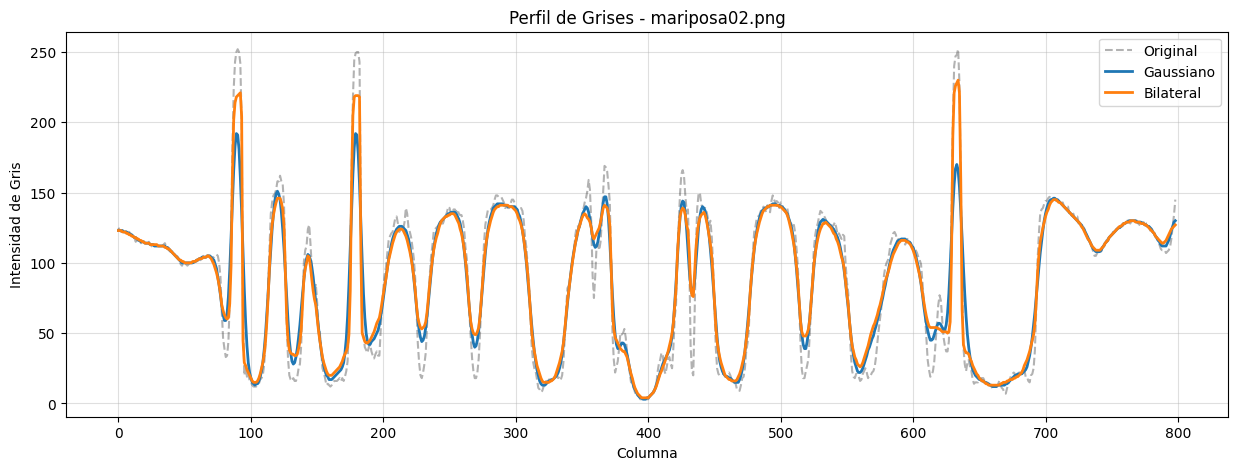


Procesando: flores02.jpg


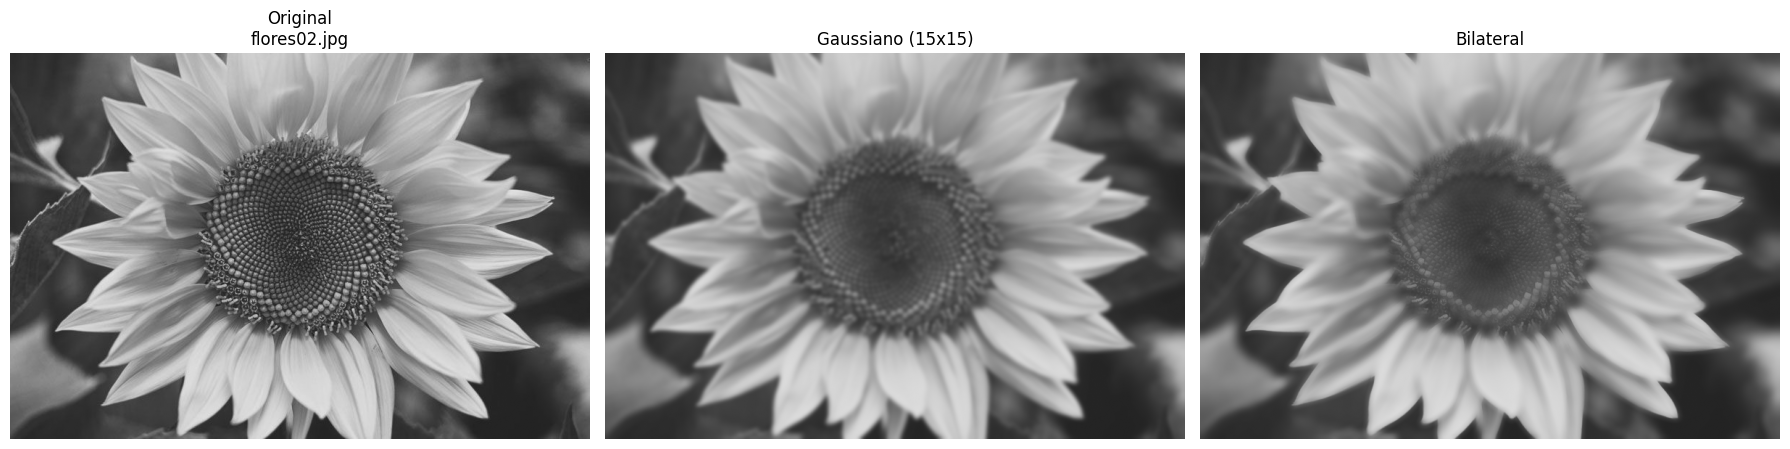

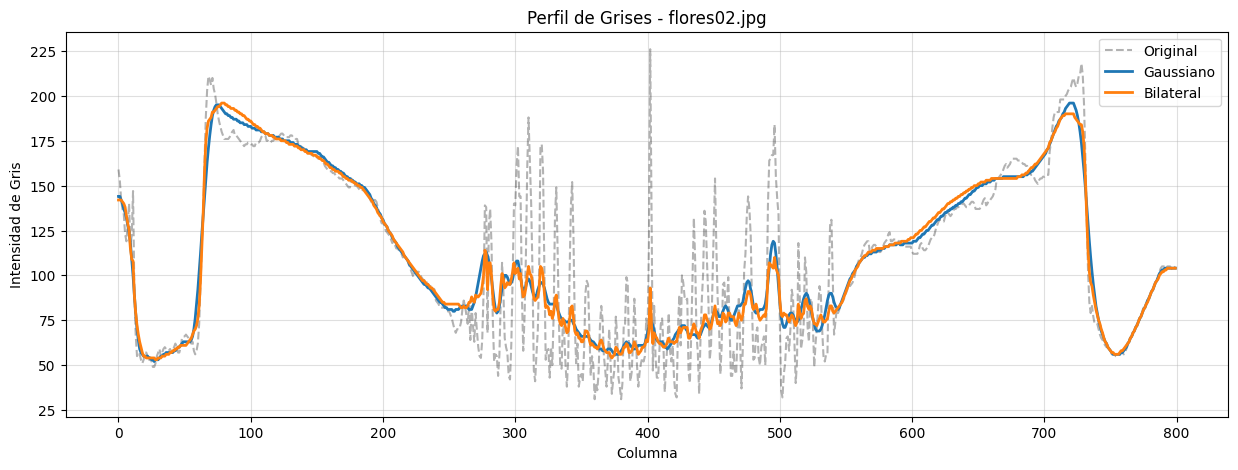

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("--- PUNTO 4.2: Comparación Bilateral vs Gaussiano ---")

# Lista de imágenes
imagenes = [
    "lapices02.jpg",
    "mariposa02.png",
    "flores02.jpg"
]

for img_path in imagenes:

    print(f"\nProcesando: {img_path}")

    img_test = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img_test is None:
        print(f"❌ Error: No se encuentra '{img_path}'.")
        continue

    # -----------------------------------
    # FILTROS
    # -----------------------------------

    # Gaussiano
    img_gauss = cv2.GaussianBlur(img_test, (15, 15), 0)

    # Bilateral
    img_bilateral = cv2.bilateralFilter(
        img_test,
        d=15,
        sigmaColor=80,
        sigmaSpace=80
    )

    # -----------------------------------
    # VISUALIZACIÓN IMÁGENES
    # -----------------------------------

    plt.figure(figsize=(18,5))

    plt.subplot(1,3,1)
    plt.imshow(img_test, cmap='gray', vmin=0, vmax=255)
    plt.title(f"Original\n{img_path}")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(img_gauss, cmap='gray', vmin=0, vmax=255)
    plt.title("Gaussiano (15x15)")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img_bilateral, cmap='gray', vmin=0, vmax=255)
    plt.title("Bilateral")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # -----------------------------------
    # PUNTO 4.3 PERFIL DE GRISES
    # -----------------------------------

    fila = img_test.shape[0] // 2

    perfil_original = img_test[fila, :]
    perfil_gauss = img_gauss[fila, :]
    perfil_bilateral = img_bilateral[fila, :]

    plt.figure(figsize=(15,5))
    plt.title(f"Perfil de Grises - {img_path}")

    plt.plot(perfil_original,
             label='Original',
             color='black',
             alpha=0.3,
             linestyle='--')

    plt.plot(perfil_gauss,
             label='Gaussiano',
             linewidth=2)

    plt.plot(perfil_bilateral,
             label='Bilateral',
             linewidth=2)

    plt.xlabel("Columna")
    plt.ylabel("Intensidad de Gris")
    plt.legend()
    plt.grid(True, alpha=0.4)

    plt.show()